In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from cycler import cycler

main_colours = plt.cm.rainbow(np.linspace(0, 1, 20))

custom_params = {
    "xtick.direction": "in",
    "ytick.direction": "in",
    "lines.markeredgecolor": "#131313",
    "lines.markeredgewidth": 1.25,
    "figure.dpi": 200,
    "text.usetex": True,
    "font.family": "serif",
    "axes.prop_cycle": cycler(color=main_colours),
}

sns.set_theme(context="talk", style="ticks", rc=custom_params)

In [ ]:
rng = np.random.default_rng(42)

plt.rcParams.update(
    {
        "figure.figsize": (5, 4),
        "axes.grid": True,
        "font.size": 11,
    }
)

In [8]:
# Time discretization
dt = 1e-2
T = 500.0
n_steps = int(T / dt)
time = np.arange(n_steps + 1) * dt

# Ensemble size
n_particles = 2000

# Physical parameters
D_t = 0.01  # translational diffusion coefficient
v0 = 1.0  # self-propulsion speed
D_r = 0.5  # rotational diffusion coefficient for ABP
alpha = 0.05  # tumbling rate for RNT

print(f"n_steps = {n_steps}")
print(f"n_particles = {n_particles}")
print(f"Total simulated points per process = {(n_steps + 1) * n_particles:,}")

n_steps = 50000
n_particles = 2000
Total simulated points per process = 100,002,000


In [ ]:
def simulate_passive_brownian(n_particles, n_steps, dt, D_t, rng):
    positions = np.zeros((n_particles, n_steps + 1, 2), dtype=float)
    noise = np.sqrt(2 * D_t * dt) * rng.normal(size=(n_particles, n_steps, 2))
    positions[:, 1:, :] = np.cumsum(noise, axis=1)
    return positions


def simulate_abp(n_particles, n_steps, dt, D_t, D_r, v0, rng):
    positions = np.zeros((n_particles, n_steps + 1, 2), dtype=float)
    theta = rng.uniform(0, 2 * np.pi, size=n_particles)

    sqrt_2Dt_dt = np.sqrt(2 * D_t * dt)
    sqrt_2Dr_dt = np.sqrt(2 * D_r * dt)

    for k in range(n_steps):
        direction = np.column_stack((np.cos(theta), np.sin(theta)))
        positions[:, k + 1, :] = (
            positions[:, k, :]
            + v0 * direction * dt
            + sqrt_2Dt_dt * rng.normal(size=(n_particles, 2))
        )
        theta += sqrt_2Dr_dt * rng.normal(size=n_particles)

    return positions


def simulate_rtp(n_particles, n_steps, dt, D_t, alpha, v0, rng):
    positions = np.zeros((n_particles, n_steps + 1, 2), dtype=float)
    theta = rng.uniform(0, 2 * np.pi, size=n_particles)

    sqrt_2Dt_dt = np.sqrt(2 * D_t * dt)

    for k in range(n_steps):
        tumble = rng.random(n_particles) < alpha * dt
        theta[tumble] = rng.uniform(0, 2 * np.pi, size=np.sum(tumble))

        direction = np.column_stack((np.cos(theta), np.sin(theta)))
        positions[:, k + 1, :] = (
            positions[:, k, :]
            + v0 * direction * dt
            + sqrt_2Dt_dt * rng.normal(size=(n_particles, 2))
        )

    return positions

## 3. Run the simulations

In [ ]:
passive = simulate_passive_brownian(n_particles, n_steps, dt, D_t, rng)
abp = simulate_abp(n_particles, n_steps, dt, D_t, D_r, v0, rng)
rtp = simulate_rtp(n_particles, n_steps, dt, D_t, alpha, v0, rng)

Done....
passive shape: (2000, 50001, 2)
abp shape: (2000, 50001, 2)
rtp shape: (2000, 50001, 2)


## 4. Plot representative trajectories

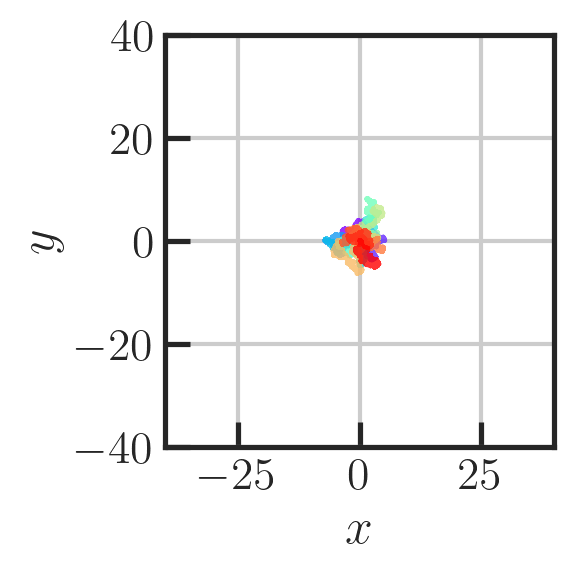

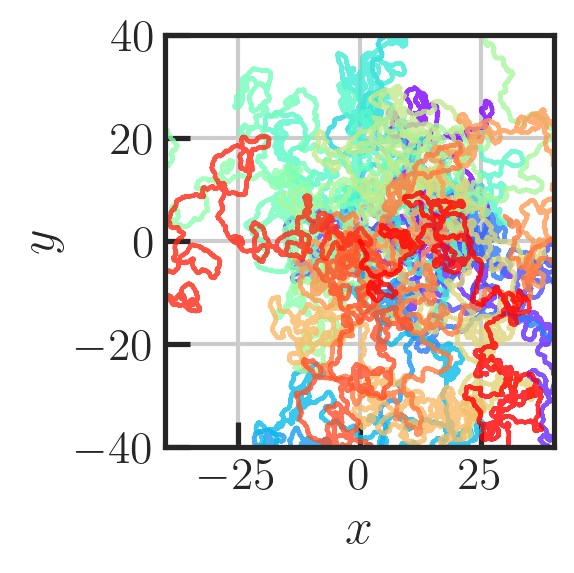

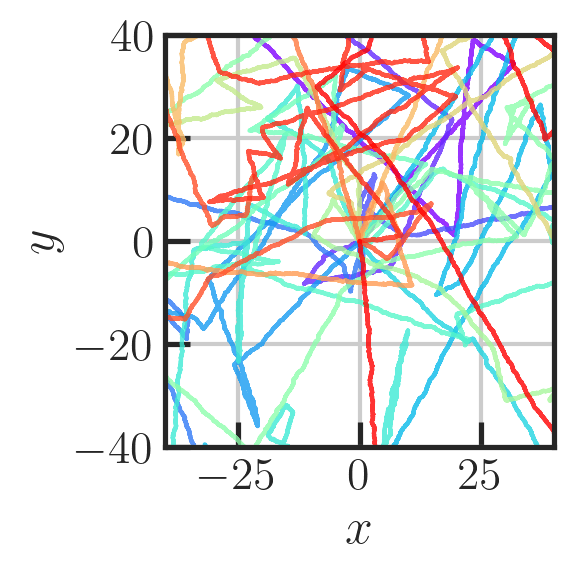

In [11]:
def plot_trajectories(positions, title, n_show=20):
    plt.figure(figsize=(3, 3))

    colors = plt.cm.rainbow(np.linspace(0, 1, n_show))

    for i, color in enumerate(colors):
        plt.plot(positions[i, :, 0], positions[i, :, 1], color=color, alpha=0.8, lw=1.5)

    # plt.scatter([0], [0], marker="x", s=70, c="k", label="Start", zorder=n_show + 1)

    # plt.axis("equal")
    plt.xlabel(r"$x$")
    plt.ylabel(r"$y$")
    # plt.title(title)
    plt.xlim(-40, 40)
    plt.ylim(-40, 40)
    # plt.legend(frameon=False)
    plt.tight_layout()
    # plt.savefig(title, transparent=True)
    plt.show()


plot_trajectories(passive, "Passive_traj.pdf")
plot_trajectories(abp, "ABP_traj.pdf")
plot_trajectories(rtp, "RNT_traj.pdf")

## 5. Plot final-position clouds

This gives a visual intuition for how much space each process explores after the same total time.

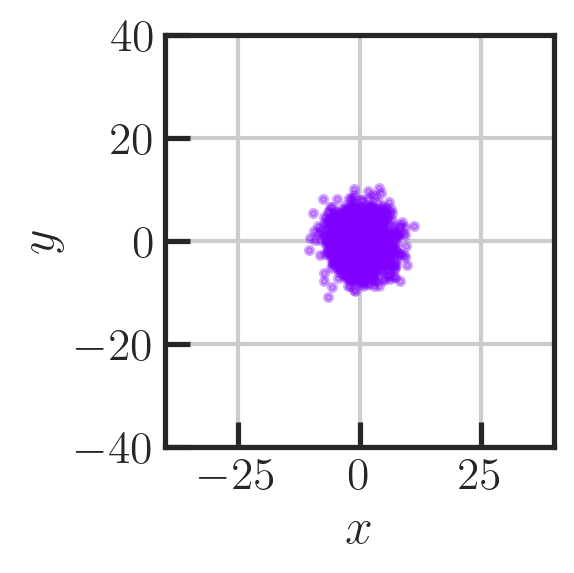

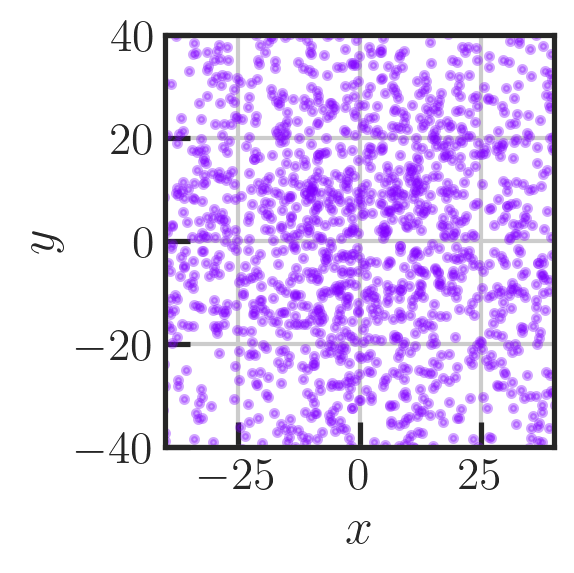

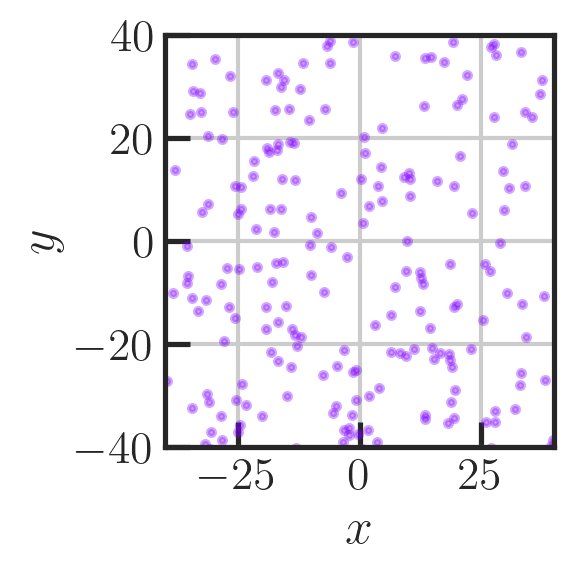

In [ ]:
def plot_cloud(positions):
    final = positions[:, -1, :]
    plt.figure(figsize=(3, 3))
    plt.scatter(final[:, 0], final[:, 1], s=6, alpha=0.35)
    # plt.axis("equal")
    plt.xlabel(r"$x$")
    plt.ylabel(r"$y$")
    plt.xlim(-40, 40)
    plt.ylim(-40, 40)
    plt.tight_layout()
    # plt.title(title)
    # plt.savefig(title, transparent=True)
    plt.show()


plot_cloud(passive)
plot_cloud(abp)
plot_cloud(rtp)

In [13]:
DT = 4.19e-21 / (6 * np.pi * 1e-2 * 10e-6)
DR = 4.19e-21 / (8 * np.pi * 1e-2 * (10e-6) ** 3)

print(DT, DR)

print(100 / 2.2e-3)

2.2228640385168047e-15 1.6671480288876033e-05
45454.54545454545


In [14]:
def ensemble_msd_from_origin(positions):
    squared_displacement = np.sum((positions - positions[:, :1, :]) ** 2, axis=2)
    return np.mean(squared_displacement, axis=0)


msd_passive = ensemble_msd_from_origin(passive)
msd_abp = ensemble_msd_from_origin(abp)
msd_rtp = ensemble_msd_from_origin(rtp)

In [15]:
def msd_theory_passive(t, D_t):
    return 4 * D_t * t


def msd_theory_abp(t, D_t, D_r, v0):
    return 4 * D_t * t + 2 * v0**2 / D_r * (t - (1 - np.exp(-D_r * t)) / D_r)


def msd_theory_rtp(t, D_t, alpha, v0):
    return 4 * D_t * t + 2 * v0**2 / alpha * (t - (1 - np.exp(-alpha * t)) / alpha)


theory_passive = msd_theory_passive(time, D_t)
theory_abp = msd_theory_abp(time, D_t, D_r, v0)
theory_rtp = msd_theory_rtp(time, D_t, alpha, v0)

D_eff_passive = D_t
D_eff_abp = D_t + v0**2 / (2 * D_r)
D_eff_rtp = D_t + v0**2 / (2 * alpha)

print(f"D_eff passive = {D_eff_passive:.3f}")
print(f"D_eff ABP     = {D_eff_abp:.3f}")
print(f"D_eff RTP     = {D_eff_rtp:.3f}")

D_eff passive = 0.010
D_eff ABP     = 1.010
D_eff RTP     = 10.010


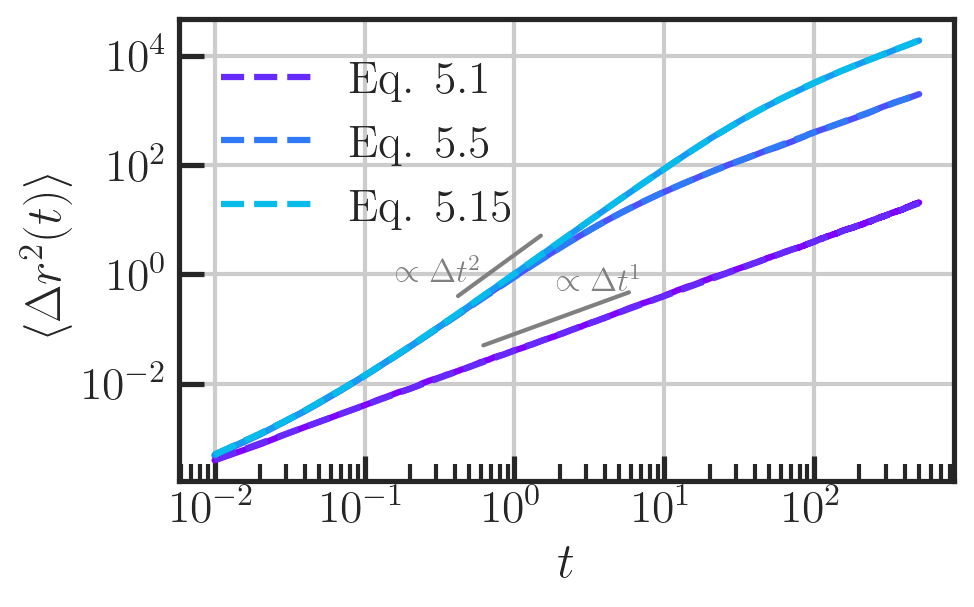

In [18]:
fig, ax = plt.subplots(figsize=(5, 3))


ax.loglog(
    time[1:],
    msd_passive[1:],
    label=None,
)  # label="Passive")
ax.loglog(time[1:], theory_passive[1:], "--", label="Eq. 5.1")

ax.loglog(
    time[1:],
    msd_abp[1:],
    label=None,
)  # label="ABP")
ax.loglog(time[1:], theory_abp[1:], "--", label="Eq. 5.5")

ax.loglog(
    time[1:],
    msd_rtp[1:],
    label=None,
)  # "RTP")
ax.loglog(time[1:], theory_rtp[1:], "--", label="Eq. 5.15")


def add_slope_guide(
    ax, x0, x1, y0, slope, text, text_offset=(1.05, 1.05), color="0.5", lw=1.5
):
    """
    Add a slope guide y ~ x^slope between x0 and x1,
    anchored so that y(x0)=y0.
    """
    x = np.array([x0, x1])
    y = y0 * (x / x0) ** slope
    ax.loglog(x, y, color=color, lw=lw)

    xm = np.sqrt(x0 * x1)
    ym = y0 * (xm / x0) ** slope
    ax.text(
        xm * text_offset[0],
        ym * text_offset[1],
        text,
        color=color,
        fontsize=12,
        ha="left",
        va="bottom",
    )


# grey slope guides
add_slope_guide(
    ax,
    x0=0.62,
    x1=5.8,
    y0=0.05,
    slope=1,
    text=r"$ \propto \Delta t^{1}$",
    text_offset=(1.00, 2.5),
)
add_slope_guide(
    ax,
    x0=0.42,
    x1=1.5,
    y0=0.4,
    slope=2,
    text=r"$\propto \Delta t^{2}$",
    text_offset=(0.2, 0.4),
)

ax.set_xlabel(r"$t$")
ax.set_ylabel(r"$\langle \Delta r^2(t)\rangle$")
ax.legend(frameon=False, ncols=1)
plt.savefig(
    "/Users/juls/Desktop/thesis/figures/chapter5/msd_abp_rtp.pdf", transparent=True
)

plt.show()

In [ ]:
def estimate_long_time_diffusion(time, msd, fit_fraction=0.4):

    start = int((1 - fit_fraction) * len(time))
    coeffs = np.polyfit(time[start:], msd[start:], deg=1)
    slope, intercept = coeffs
    return slope / 4, slope, intercept


D_fit_passive, slope_passive, _ = estimate_long_time_diffusion(time, msd_passive)
D_fit_abp, slope_abp, _ = estimate_long_time_diffusion(time, msd_abp)
D_fit_rtp, slope_rtp, _ = estimate_long_time_diffusion(time, msd_rtp)

print(f"Passive: simulation {D_fit_passive:.3f}, theory {D_eff_passive:.3f}")
print(f"ABP:     simulation {D_fit_abp:.3f}, theory {D_eff_abp:.3f}")
print(f"RTP:     simulation {D_fit_rtp:.3f}, theory {D_eff_rtp:.3f}")

Long-time diffusion estimates
-----------------------------
Passive: simulation 0.011, theory 0.010
ABP:     simulation 0.938, theory 1.010
RTP:     simulation 9.839, theory 10.010


## 11. D

In [20]:
import pandas as pd

summary = pd.DataFrame(
    {
        "process": ["Passive Brownian", "ABP", "RTP"],
        "theory D_eff": [D_eff_passive, D_eff_abp, D_eff_rtp],
        "fitted D_eff": [D_fit_passive, D_fit_abp, D_fit_rtp],
    }
)

summary["relative error"] = (
    summary["fitted D_eff"] - summary["theory D_eff"]
) / summary["theory D_eff"]

summary

,process,theory D_eff,fitted D_eff,relative error
0,Passive Brownian,0.01,0.010905,0.090508
1,ABP,1.01,0.938470,-0.070822
2,RTP,10.01,9.839450,-0.017038


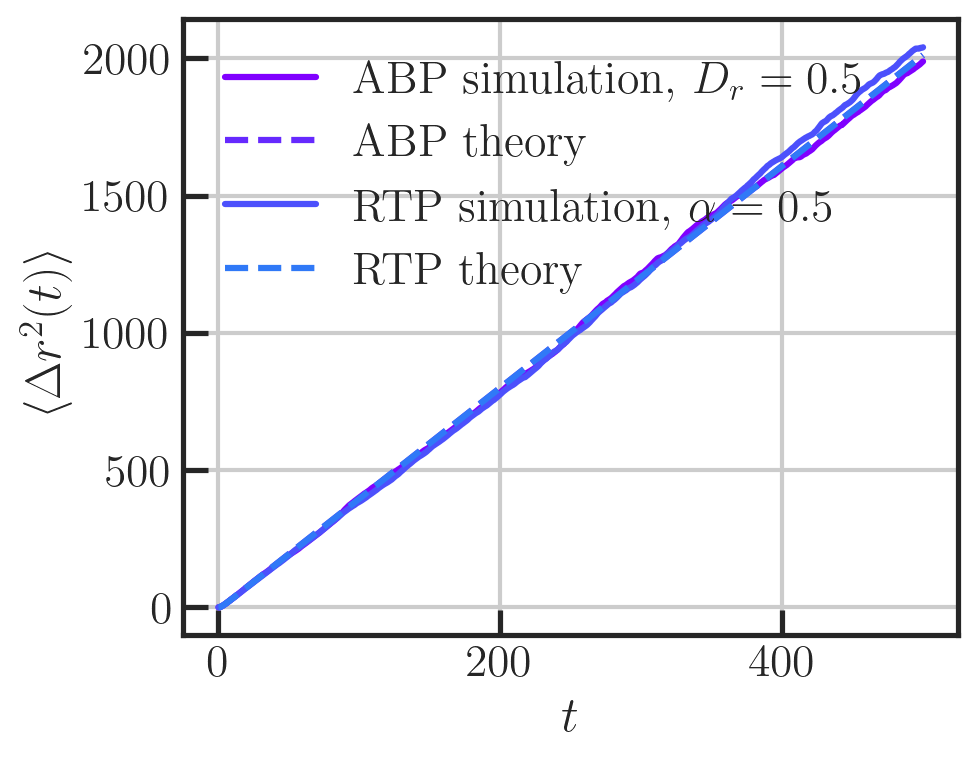

In [21]:
alpha_matched = D_r

rtp_matched = simulate_rtp(n_particles, n_steps, dt, D_t, alpha_matched, v0, rng)
msd_rtp_matched = ensemble_msd_from_origin(rtp_matched)
theory_rtp_matched = msd_theory_rtp(time, D_t, alpha_matched, v0)

plt.figure()
plt.plot(time, msd_abp, label=rf"ABP simulation, $D_r={D_r}$")
plt.plot(time, theory_abp, "--", label="ABP theory")

plt.plot(time, msd_rtp_matched, label=rf"RTP simulation, $\alpha={alpha_matched}$")
plt.plot(time, theory_rtp_matched, "--", label="RTP theory")

plt.xlabel(r"$t$")
plt.ylabel(r"$\langle \Delta r^2(t)\rangle$")
plt.legend(frameon=False)
plt.show()

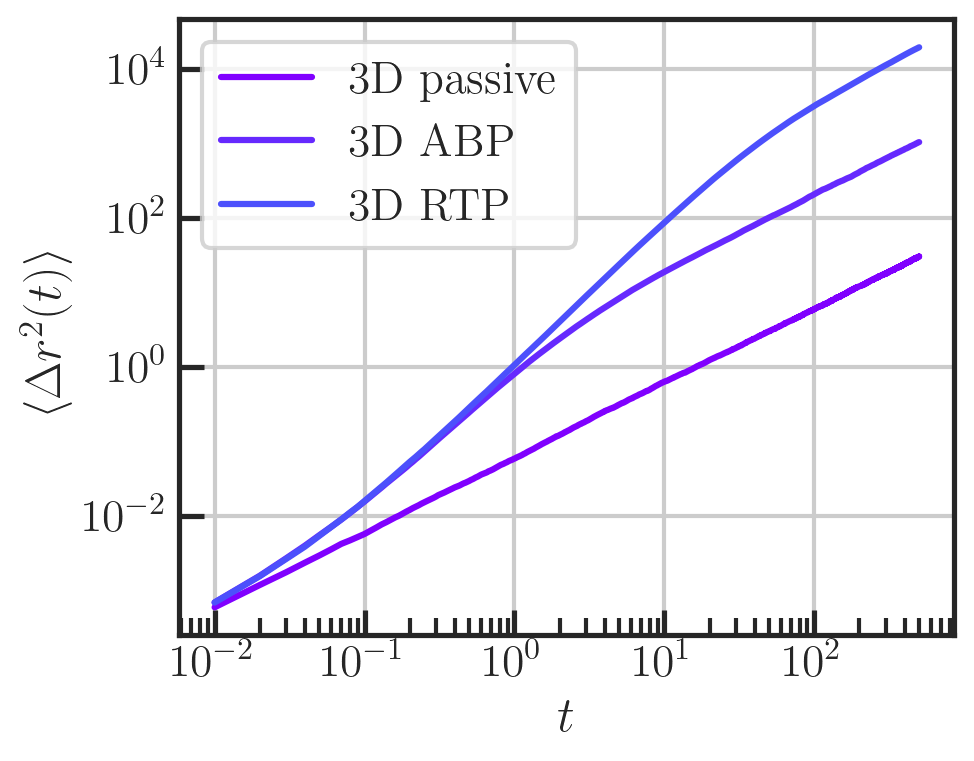

In [22]:
def random_unit_vectors_3d(n, rng):
    vec = rng.normal(size=(n, 3))
    return vec / np.linalg.norm(vec, axis=1, keepdims=True)


def simulate_passive_brownian_3d(n_particles, n_steps, dt, D_t, rng):
    positions = np.zeros((n_particles, n_steps + 1, 3))
    noise = np.sqrt(2 * D_t * dt) * rng.normal(size=(n_particles, n_steps, 3))
    positions[:, 1:, :] = np.cumsum(noise, axis=1)
    return positions


def simulate_abp_3d(n_particles, n_steps, dt, D_t, D_r, v0, rng):
    positions = np.zeros((n_particles, n_steps + 1, 3))
    directions = random_unit_vectors_3d(n_particles, rng)

    for k in range(n_steps):
        positions[:, k + 1, :] = (
            positions[:, k, :]
            + v0 * directions * dt
            + np.sqrt(2 * D_t * dt) * rng.normal(size=(n_particles, 3))
        )

        # Rotational diffusion, projected back onto the unit sphere
        directions += np.sqrt(2 * D_r * dt) * rng.normal(size=(n_particles, 3))
        directions /= np.linalg.norm(directions, axis=1, keepdims=True)

    return positions


def simulate_rtp_3d(n_particles, n_steps, dt, D_t, alpha, v0, rng):
    positions = np.zeros((n_particles, n_steps + 1, 3))
    directions = random_unit_vectors_3d(n_particles, rng)

    for k in range(n_steps):
        tumble = rng.random(n_particles) < alpha * dt
        directions[tumble] = random_unit_vectors_3d(np.sum(tumble), rng)

        positions[:, k + 1, :] = (
            positions[:, k, :]
            + v0 * directions * dt
            + np.sqrt(2 * D_t * dt) * rng.normal(size=(n_particles, 3))
        )

    return positions


def ensemble_msd_from_origin_nd(positions):
    return np.mean(np.sum((positions - positions[:, :1, :]) ** 2, axis=2), axis=0)


passive_3d = simulate_passive_brownian_3d(n_particles, n_steps, dt, D_t, rng)
abp_3d = simulate_abp_3d(n_particles, n_steps, dt, D_t, D_r, v0, rng)
rtp_3d = simulate_rtp_3d(n_particles, n_steps, dt, D_t, alpha, v0, rng)

msd_passive_3d = ensemble_msd_from_origin_nd(passive_3d)
msd_abp_3d = ensemble_msd_from_origin_nd(abp_3d)
msd_rtp_3d = ensemble_msd_from_origin_nd(rtp_3d)

plt.figure()
plt.loglog(time[1:], msd_passive_3d[1:], label="3D passive")
plt.loglog(time[1:], msd_abp_3d[1:], label="3D ABP")
plt.loglog(time[1:], msd_rtp_3d[1:], label="3D RTP")

plt.xlabel(r"$t$")
plt.ylabel(r"$\langle \Delta r^2(t)\rangle$")
plt.legend()
plt.show()

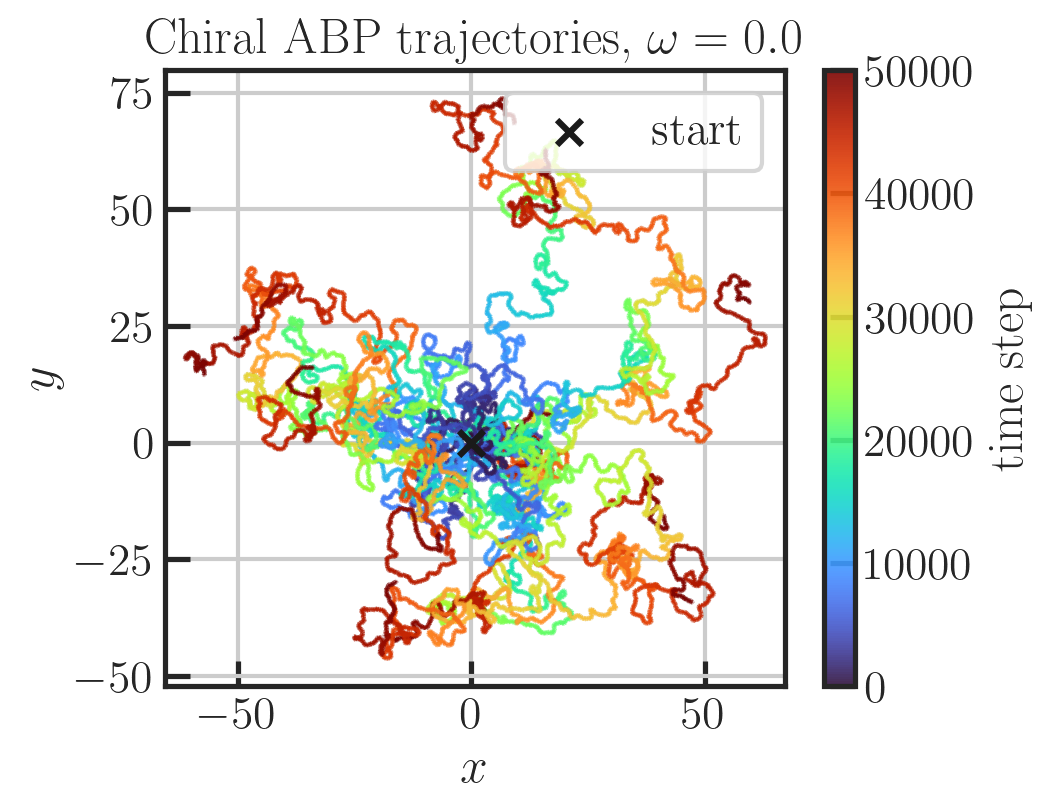

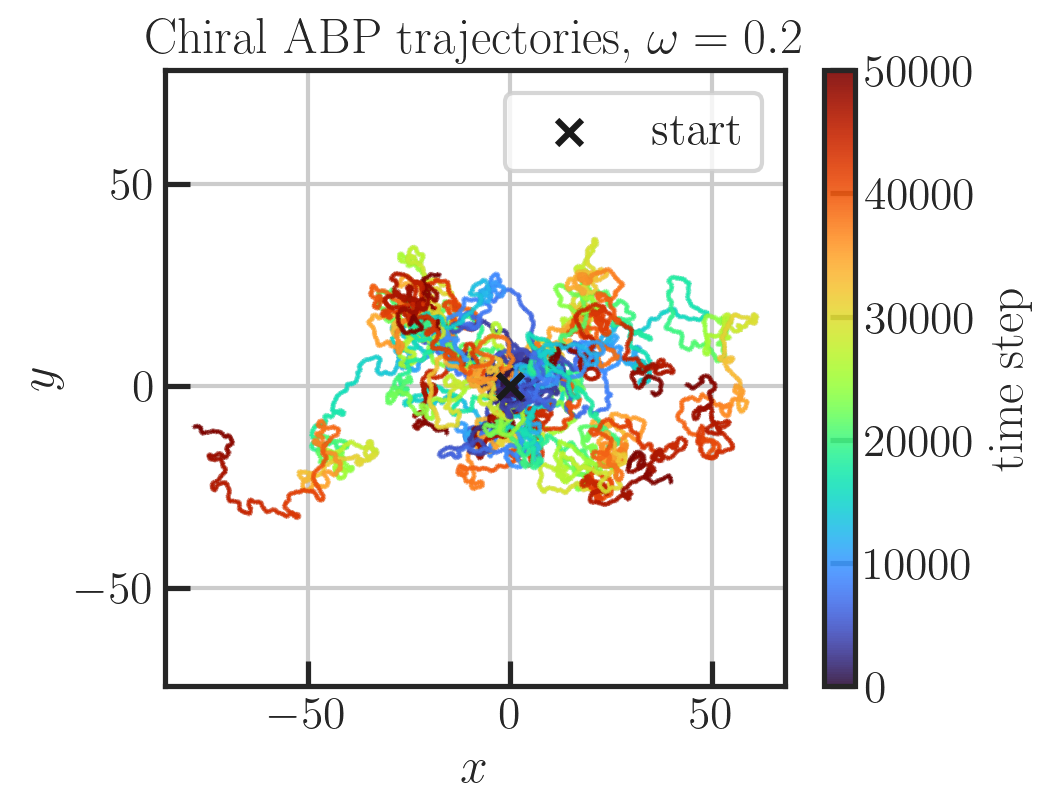

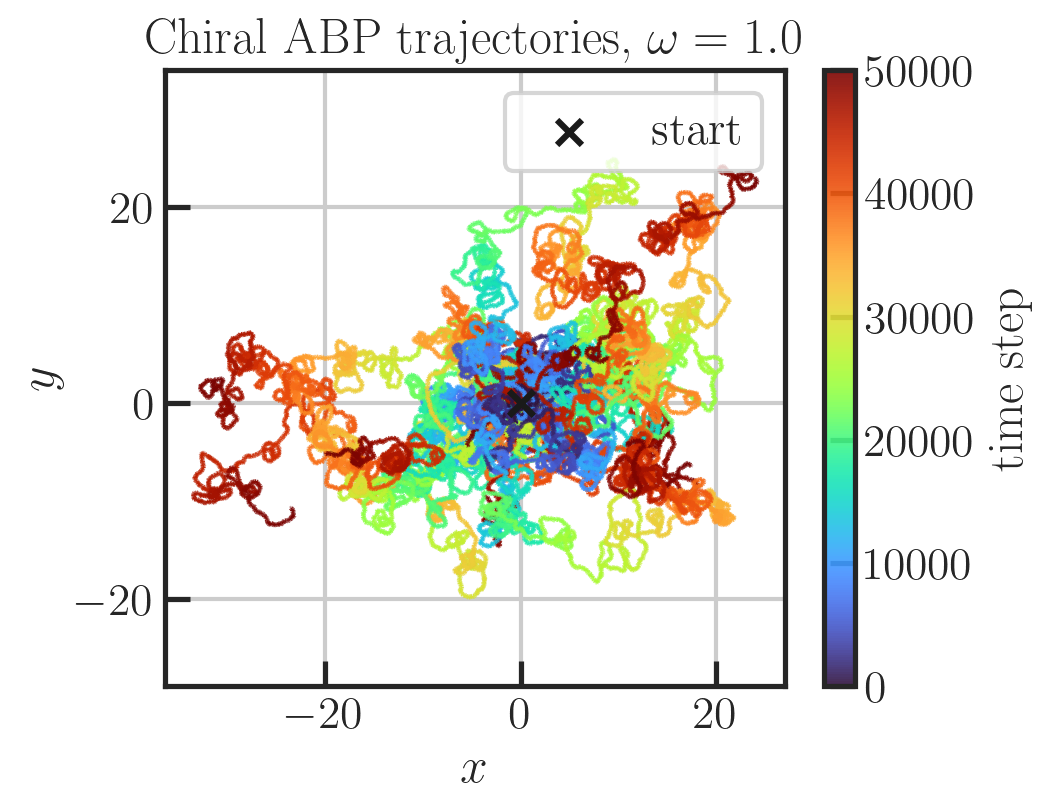

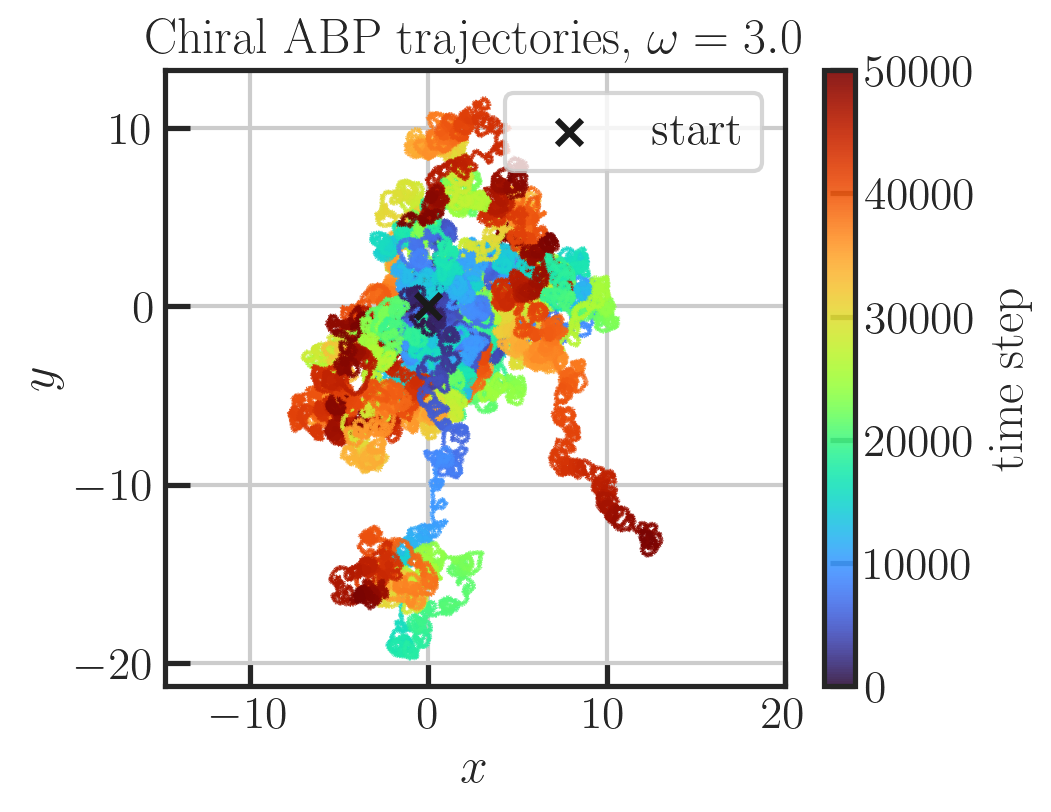

In [ ]:
def simulate_chiral_abp(n_particles, n_steps, dt, D_t, D_r, v0, omega, rng):
    positions = np.zeros((n_particles, n_steps + 1, 2))
    theta = rng.uniform(0, 2 * np.pi, size=n_particles)

    for k in range(n_steps):
        e = np.column_stack((np.cos(theta), np.sin(theta)))

        positions[:, k + 1, :] = (
            positions[:, k, :]
            + v0 * e * dt
            + np.sqrt(2 * D_t * dt) * rng.normal(size=(n_particles, 2))
        )

        theta += omega * dt + np.sqrt(2 * D_r * dt) * rng.normal(size=n_particles)

    return positions


from matplotlib.collections import LineCollection


def plot_trajectories_rainbow_time(positions, n_show=15, cmap_name="turbo"):
    fig, ax = plt.subplots()

    cmap = plt.get_cmap(cmap_name)
    norm = plt.Normalize(0, positions.shape[1] - 1)

    last_lc = None

    for i in range(n_show):
        x = positions[i, :, 0]
        y = positions[i, :, 1]

        points = np.array([x, y]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)

        lc = LineCollection(segments, cmap=cmap, norm=norm)
        lc.set_array(np.arange(len(x) - 1))
        lc.set_linewidth(1.8)
        lc.set_alpha(0.9)

        ax.add_collection(lc)
        last_lc = lc

    ax.scatter([0], [0], marker="x", s=80, c="k", label="start", zorder=5)

    ax.axis("equal")
    ax.autoscale()
    ax.set_xlabel(r"$x$")
    ax.set_ylabel(r"$y$")
    ax.legend()

    cbar = fig.colorbar(last_lc, ax=ax)
    cbar.set_label("time step")

    plt.show()


omega_values = [0.0, 0.2, 1.0, 3.0]

chiral_positions = {}
chiral_msds = {}

for omega in omega_values:
    chiral_positions[omega] = simulate_chiral_abp(
        n_particles=n_particles,
        n_steps=n_steps,
        dt=dt,
        D_t=D_t,
        D_r=D_r,
        v0=v0,
        omega=omega,
        rng=rng,
    )

    chiral_msds[omega] = ensemble_msd_from_origin(chiral_positions[omega])


for omega in omega_values:
    plot_trajectories_rainbow_time(
        chiral_positions[omega],
        n_show=12,
        cmap_name="rainbow",
    )

In [24]:
def msd_theory_chiral_abp(t, D_t, D_r, omega, v0):
    t = np.asarray(t, dtype=float)

    a = -D_r + 1j * omega

    # integral_0^t (t-s) exp(a s) ds
    integral = (np.exp(a * t) - 1 - a * t) / a**2

    return 4 * D_t * t + 2 * v0**2 * np.real(integral)


def D_eff_chiral_abp(D_t, D_r, omega, v0):
    return D_t + 0.5 * v0**2 * D_r / (D_r**2 + omega**2)


chiral_theory_msds = {
    omega: msd_theory_chiral_abp(time, D_t, D_r, omega, v0) for omega in omega_values
}

chiral_D_eff_theory = {
    omega: D_eff_chiral_abp(D_t, D_r, omega, v0) for omega in omega_values
}

chiral_D_eff_fit = {
    omega: estimate_long_time_diffusion(time, chiral_msds[omega])[0]
    for omega in omega_values
}

for omega in omega_values:
    print(
        f"omega={omega:>3}: "
        f"D_eff theory={chiral_D_eff_theory[omega]:.4f}, "
        f"D_eff fitted={chiral_D_eff_fit[omega]:.4f}"
    )

omega=0.0: D_eff theory=1.0100, D_eff fitted=1.0068
omega=0.2: D_eff theory=0.8721, D_eff fitted=0.8940
omega=1.0: D_eff theory=0.2100, D_eff fitted=0.2252
omega=3.0: D_eff theory=0.0370, D_eff fitted=0.0363


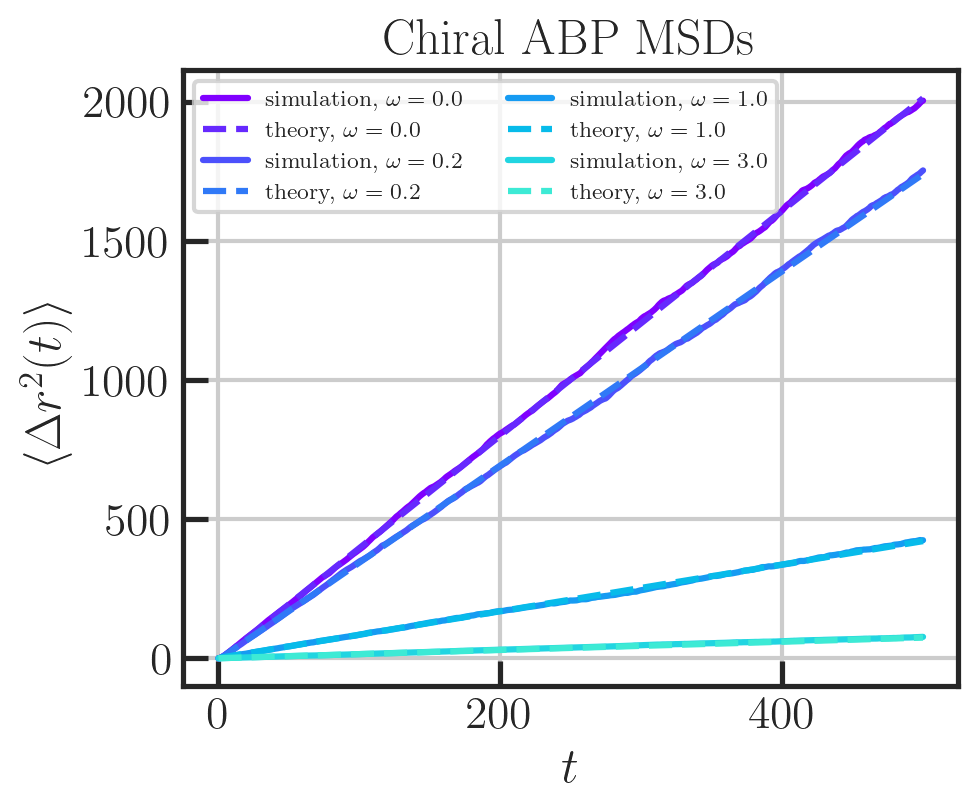

In [ ]:
plt.figure()

for omega in omega_values:
    plt.plot(time, chiral_msds[omega], label=rf"simulation, $\omega={omega}$")
    plt.plot(time, chiral_theory_msds[omega], "--", label=rf"theory, $\omega={omega}$")

plt.xlabel(r"$t$")
plt.ylabel(r"$\langle \Delta r^2(t)\rangle$")
plt.legend(ncol=2, fontsize=8)
plt.show()

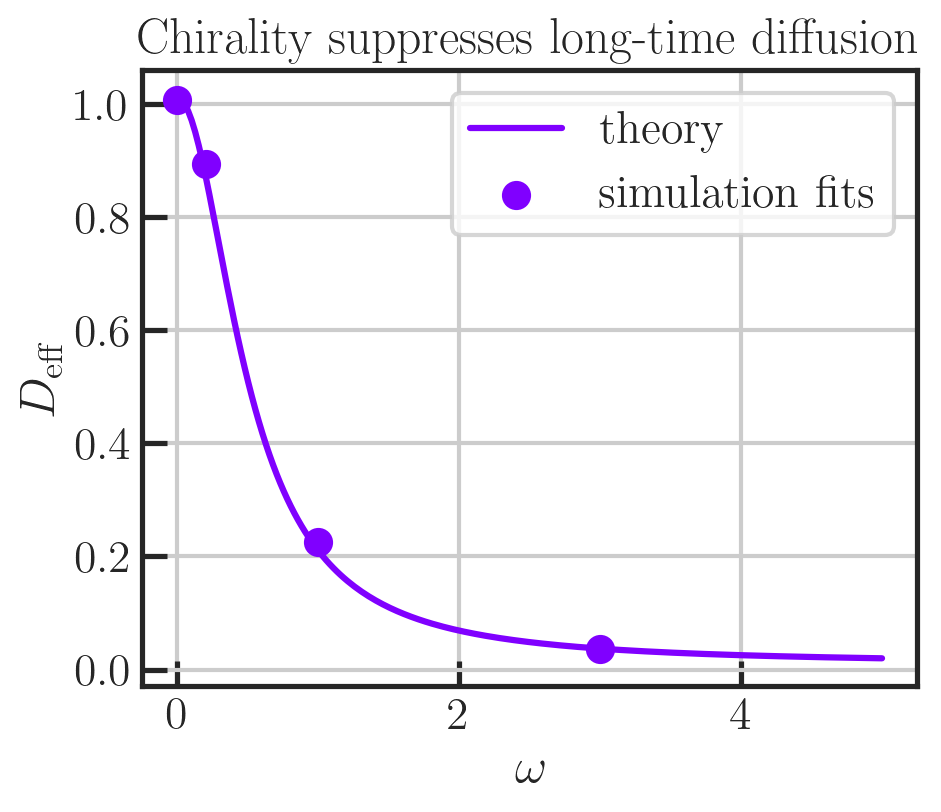

In [ ]:
omega_scan = np.linspace(0, 5, 200)
D_eff_scan = D_eff_chiral_abp(D_t, D_r, omega_scan, v0)

plt.figure()
plt.plot(omega_scan, D_eff_scan, label="theory")
plt.scatter(
    omega_values,
    [chiral_D_eff_fit[omega] for omega in omega_values],
    zorder=5,
    label="simulation fits",
)

plt.xlabel(r"$\omega$")
plt.ylabel(r"$D_\mathrm{eff}$")
plt.legend()
plt.show()

In [ ]:
from mpl_toolkits.mplot3d.art3d import Line3DCollection


def normalize_vectors(v):
    return v / np.linalg.norm(v, axis=1, keepdims=True)


def simulate_3d_helical_swimmer(
    n_particles,
    n_steps,
    dt,
    D_t,
    D_r,
    v0,
    omega,
    pitch_angle,
    rng,
):
    positions = np.zeros((n_particles, n_steps + 1, 3))

    phi = rng.uniform(0, 2 * np.pi, size=n_particles)

    n = np.column_stack(
        (
            np.sin(pitch_angle) * np.cos(phi),
            np.sin(pitch_angle) * np.sin(phi),
            np.cos(pitch_angle) * np.ones(n_particles),
        )
    )

    ez = np.array([0.0, 0.0, 1.0])

    sqrt_2Dt_dt = np.sqrt(2 * D_t * dt)
    sqrt_2Dr_dt = np.sqrt(2 * D_r * dt)

    for k in range(n_steps):
        positions[:, k + 1, :] = (
            positions[:, k, :]
            + v0 * n * dt
            + sqrt_2Dt_dt * rng.normal(size=(n_particles, 3))
        )

        # Deterministic chiral rotation around z
        dn_chiral = omega * np.cross(ez, n) * dt

        dOmega = sqrt_2Dr_dt * rng.normal(size=(n_particles, 3))
        dn_noise = np.cross(dOmega, n)

        n = normalize_vectors(n + dn_chiral + dn_noise)

    return positions

In [ ]:
def plot_3d_trajectory_rainbow_time(
    positions, particle_index=0, cmap_name="turbo", name="filler"
):
    """
    Plot one 3D trajectory with color evolving in time.
    """

    r = positions[particle_index]
    x, y, z = r[:, 0], r[:, 1], r[:, 2]

    points = r.reshape(-1, 1, 3)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    cmap = plt.get_cmap(cmap_name)
    norm = plt.Normalize(0, len(r) - 1)

    lc = Line3DCollection(segments, cmap=cmap, norm=norm)
    lc.set_array(np.arange(len(r) - 1))
    lc.set_linewidth(2.0)

    fig = plt.figure(figsize=(4, 4))
    ax = fig.add_subplot(111, projection="3d")
    ax.view_init(elev=20, azim=-80, roll=0)

    ax.add_collection3d(lc)
    ax.scatter([x[0]], [y[0]], [z[0]], marker="x", s=80, c="k", label="start")

    ax.set_xlim(x.min(), x.max())
    ax.set_ylim(y.min(), y.max())
    ax.set_zlim(z.min(), z.max())

    ax.set_xlabel(r"$x$")
    ax.set_ylabel(r"$y$")
    ax.set_zlabel(r"$z$")
    plt.tight_layout()

    plt.show()

In [29]:
# Parameters for the 3D helical swimmer

n_particles_3d = 20
T_3d = 800.0
dt_3d = 1e-2
n_steps_3d = int(T_3d / dt_3d)

D_t_3d = 0.005
D_r_3d = 0.01

v0_3d = 1.0
omega_3d = 1.0


pitch_angle = np.pi / 12

In [30]:
# %matplotlib widget

In [31]:
helical_3d = simulate_3d_helical_swimmer(
    n_particles=n_particles_3d,
    n_steps=n_steps_3d,
    dt=dt_3d,
    D_t=D_t_3d,
    D_r=D_r_3d,
    v0=v0_3d,
    omega=omega_3d,
    pitch_angle=pitch_angle,
    rng=rng,
)

In [32]:
np.shape(helical_3d)

(20, 80001, 3)

0.2617993877991494
0.2617993877991494


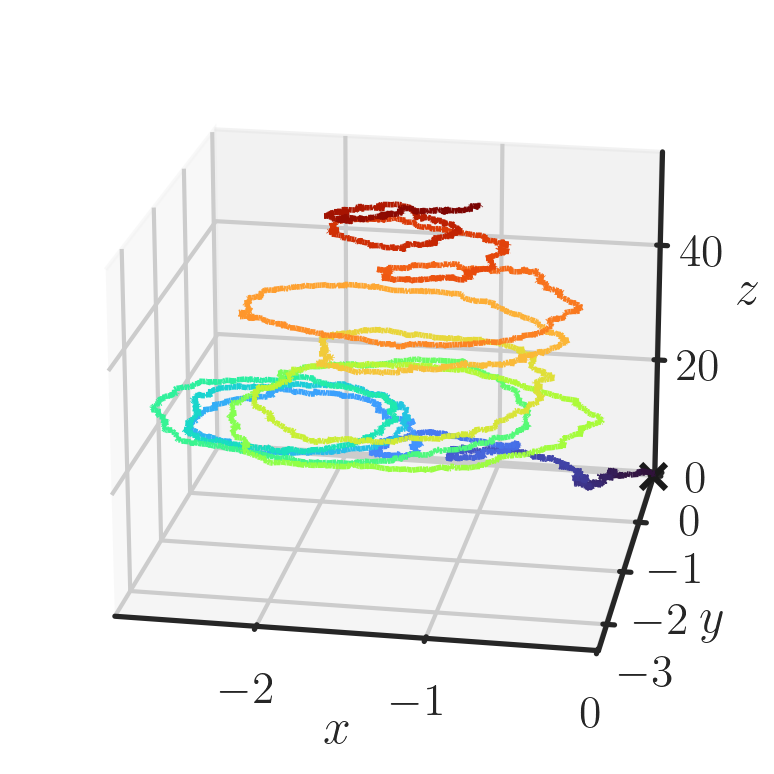

In [33]:
print(pitch_angle)
name = str(pitch_angle)
name
print(name)
plot_3d_trajectory_rainbow_time(
    helical_3d[:, :8000, :],
    title=None,
    particle_index=4,
    cmap_name="turbo",
    name=str(pitch_angle) + "_shorttimes.pdf",
)